In [1]:
import pandas as pd

df = pd.read_csv("../data/student_stress.csv")

df.head()

,study_hours,sleep_hours,screen_time,exercise_hours,exam_pressure,social_activity,stress_level
0,8,5,6,1,8,2,High
1,6,7,5,2,5,4,Moderate
2,10,4,7,0,9,1,High
3,4,8,3,3,3,5,Low
4,7,6,5,1,6,3,Moderate


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   study_hours      7 non-null      int64 
 1   sleep_hours      7 non-null      int64 
 2   screen_time      7 non-null      int64 
 3   exercise_hours   7 non-null      int64 
 4   exam_pressure    7 non-null      int64 
 5   social_activity  7 non-null      int64 
 6   stress_level     7 non-null      object
dtypes: int64(6), object(1)
memory usage: 524.0+ bytes


In [3]:
df.describe()

,study_hours,sleep_hours,screen_time,exercise_hours,exam_pressure,social_activity
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,7.000000,6.000000,5.142857,1.285714,6.142857,2.857143
std,2.160247,1.414214,1.345185,1.112697,2.267787,1.573592
min,4.000000,4.000000,3.000000,0.000000,3.000000,1.000000
25%,5.500000,5.000000,4.500000,0.500000,4.500000,1.500000
50%,7.000000,6.000000,5.000000,1.000000,6.000000,3.000000
75%,8.500000,7.000000,6.000000,2.000000,8.000000,4.000000
max,10.000000,8.000000,7.000000,3.000000,9.000000,5.000000


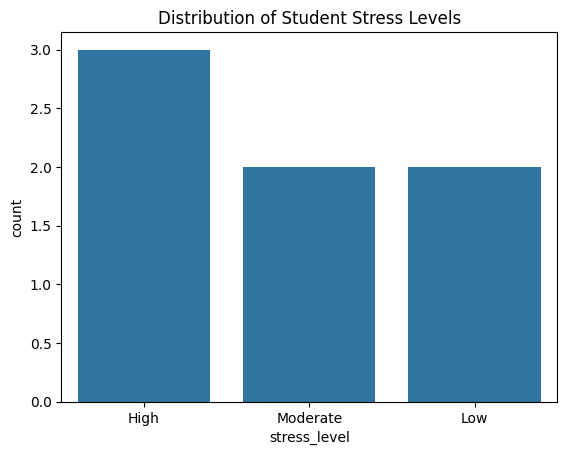

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="stress_level", data=df)

plt.title("Distribution of Student Stress Levels")

plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["stress_level"] = encoder.fit_transform(df["stress_level"])

df.head()

,study_hours,sleep_hours,screen_time,exercise_hours,exam_pressure,social_activity,stress_level
0,8,5,6,1,8,2,0
1,6,7,5,2,5,4,2
2,10,4,7,0,9,1,0
3,4,8,3,3,3,5,1
4,7,6,5,1,6,3,2


In [6]:
X = df.drop("stress_level", axis=1)

y = df["stress_level"]

X.head()

,study_hours,sleep_hours,screen_time,exercise_hours,exam_pressure,social_activity
0,8,5,6,1,8,2
1,6,7,5,2,5,4
2,10,4,7,0,9,1
3,4,8,3,3,3,5
4,7,6,5,1,6,3


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)